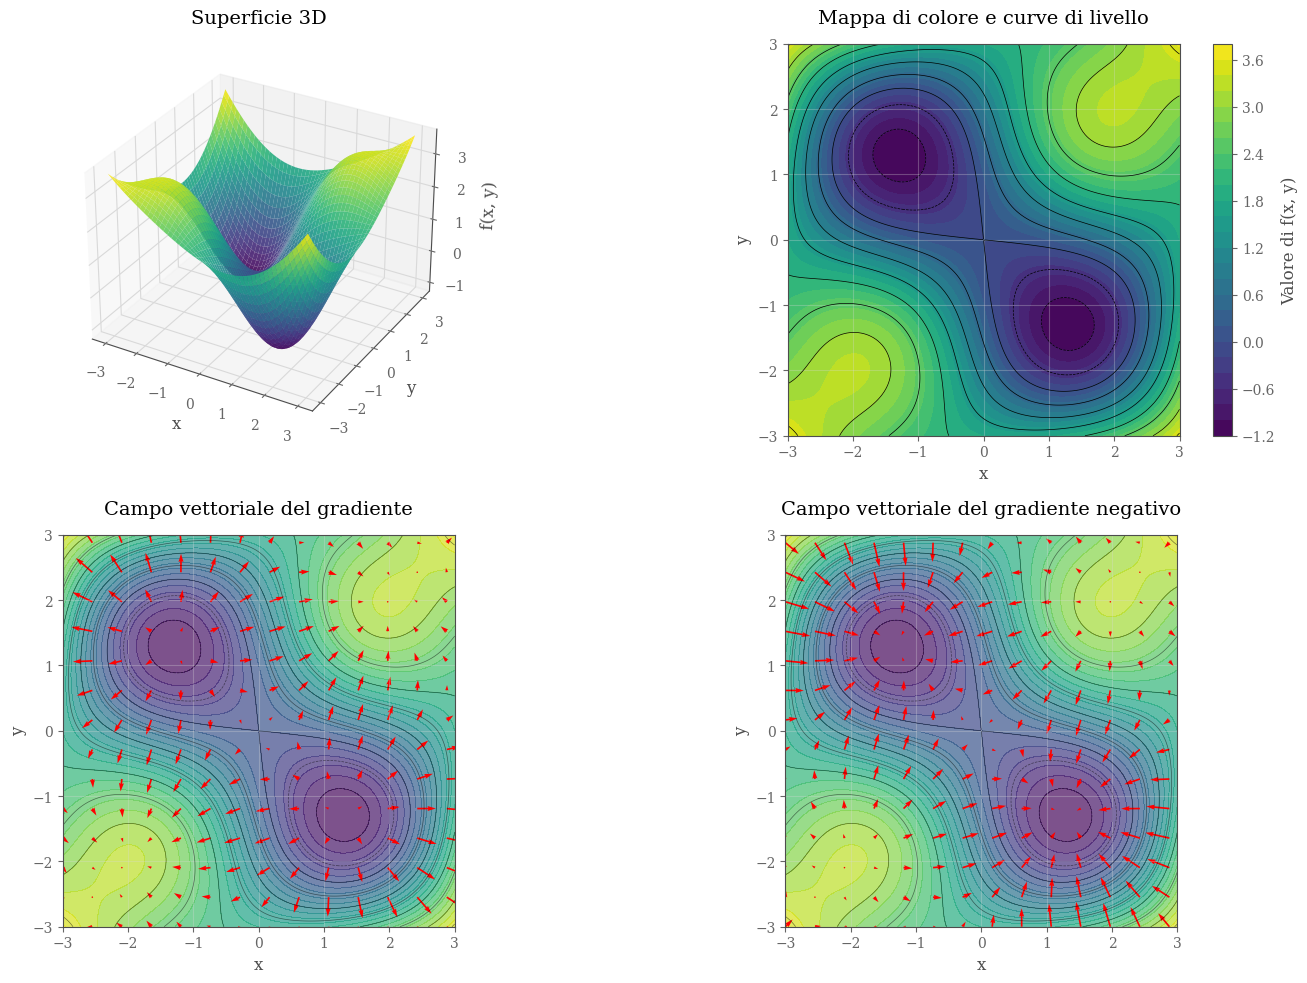

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necessario per i plot 3D

# Definizione della funzione f(x, y)
def f(x, y):
    """
    Esempio di funzione con più minimi locali.
    Puoi modificarla come preferisci.
    """
    return 0.2 * (x**2 + y**2) + 2.0 * np.sin(x) * np.sin(y)

# Definizione del gradiente di f(x, y)
def grad_f(x, y):
    """
    Calcola il gradiente di f(x, y): restituisce (df/dx, df/dy).
    """
    dfdx = 0.4 * x + 2.0 * np.cos(x) * np.sin(y)
    dfdy = 0.4 * y + 2.0 * np.sin(x) * np.cos(y)
    return dfdx, dfdy

# Creazione della griglia di punti per i plot
N = 200  # Numero di punti per dimensione
x_vals = np.linspace(-3, 3, N)
y_vals = np.linspace(-3, 3, N)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# Calcolo del gradiente su una griglia più rada per la visualizzazione del campo vettoriale
step = 15  # Passo per la selezione dei punti per il campo vettoriale
x_quiver = X[::step, ::step]
y_quiver = Y[::step, ::step]
dfdx, dfdy = grad_f(x_quiver, y_quiver)

# Creazione della figura con 2 righe e 2 colonne, usando width_ratios per modificare le dimensioni dei subplot in alto
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 2])

# -------------------------------------------------------------------------
# Pannello 1 (in alto a sinistra): Plot 3D della superficie (più grande)
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('Superficie 3D')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# -------------------------------------------------------------------------
# Pannello 2 (in alto a destra): Mappa di colore e curve di livello (più quadrato)
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
cont = ax2.contourf(X, Y, Z, levels=30, cmap='viridis')
ax2.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5)
ax2.set_title('Mappa di colore e curve di livello')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal', adjustable='box')  # Forza un aspetto quadrato
cbar = plt.colorbar(cont, ax=ax2)
cbar.set_label('Valore di f(x, y)')

# -------------------------------------------------------------------------
# Pannello 3 (in basso a sinistra): Campo vettoriale del gradiente positivo
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax3.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, alpha=0.5)
Q = ax3.quiver(x_quiver, y_quiver, dfdx, dfdy, color='red', scale=50)
ax3.set_title('Campo vettoriale del gradiente')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_aspect('equal')

# -------------------------------------------------------------------------
# Pannello 4 (in basso a destra): Campo vettoriale del gradiente negativo
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax4.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, alpha=0.5)
Q2 = ax4.quiver(x_quiver, y_quiver, -dfdx, -dfdy, color='red', scale=50)
ax4.set_title('Campo vettoriale del gradiente negativo')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_aspect('equal')

plt.tight_layout()
plt.savefig('./images/gradient.jpg', 
           dpi=300, 
           bbox_inches='tight',
           pad_inches=0.05,  # Aggiungere questo parametro
           #facecolor=fig.get_facecolor(),  # Mantenere il colore di sfondo
           transparent=False)  # Disabilitare la trasparenza
plt.show()